# Exotic Matter Distribution and Stability Analysis of a Traversable Wormhole

## Project Overview

Traversable wormholes are hypothetical solutions to Einstein's field equations that connect two separate regions of spacetime through a tunnel-like geometry. Unlike black holes, traversable wormholes possess no event horizon, allowing matter and light to travel through the throat without becoming trapped.

According to **General Relativity**, maintaining a traversable wormhole requires an unusual form of matter known as **exotic matter**. Unlike ordinary matter, exotic matter possesses **negative energy density** and violates one or more of the classical energy conditions that are normally satisfied by conventional matter.

One of the most important of these is the **Null Energy Condition (NEC)**, which is expressed as

$$
T_{\mu\nu}k^\mu k^\nu \ge 0,
$$

where

- \(T_{\mu\nu}\) is the stress-energy tensor.
- \(k^\mu\) is any null (light-like) vector.

For a static, spherically symmetric Morris–Thorne wormhole, the NEC reduces to

$$
\rho+p_r\ge0,
$$

where

- \(\rho\) is the energy density.
- \(p_r\) is the radial pressure.

A traversable wormhole requires

$$
\rho+p_r<0,
$$

indicating a violation of the Null Energy Condition. This violation implies the presence of **exotic matter**, whose negative energy density prevents the wormhole throat from collapsing under its own gravity.

In this notebook, we investigate the distribution of exotic matter required to sustain a Morris–Thorne traversable wormhole and examine whether the resulting spacetime remains stable under small perturbations. The study combines analytical results from General Relativity with numerical simulations implemented in Python to explore the physical properties of the wormhole and assess its stability.

---

## Objectives

The primary objectives of this project are to:

- Introduce the Morris–Thorne traversable wormhole metric.
- Define the wormhole shape function and its derivative.
- Compute the energy density from Einstein's field equations.
- Calculate the radial and tangential pressure distributions.
- Investigate violations of the Null Energy Condition (NEC).
- Identify the regions containing exotic matter.
- Visualize the energy density, pressure, and NEC profiles.
- Quantify the distribution of exotic matter surrounding the wormhole throat.
- Examine the stability of the wormhole under small perturbations.
- Discuss the implications of these results for realistic traversable wormholes and future observational studies.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sympy as sp

plt.style.use("ggplot")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Geometrized units

G = 1
c = 1

print("Using natural units:")
print("G =", G)
print("c =", c)

Using natural units:
G = 1
c = 1


## Working in Geometrized Units

Throughout this notebook, all calculations are performed using **geometrized units**, in which

$$
G = c = 1,
$$

where

- \(G\) is Newton's gravitational constant.
- \(c\) is the speed of light in vacuum.

By setting these fundamental constants equal to unity, the equations of General Relativity become significantly simpler. In this system, mass, length, and time are expressed in the same units, eliminating many conversion factors from the equations.

For example, the Schwarzschild radius,

$$
R_s=\frac{2GM}{c^2},
$$

reduces to the much simpler expression

$$
R_s=2M.
$$

Similarly, the Schwarzschild metric becomes

$$
ds^2=
-\left(1-\frac{2M}{r}\right)dt^2
+\left(1-\frac{2M}{r}\right)^{-1}dr^2
+r^2d\theta^2
+r^2\sin^2\theta\,d\phi^2.
$$

Using geometrized units is standard practice in General Relativity, black hole physics, and traversable wormhole research because it simplifies both the mathematical derivations and the numerical implementation while preserving the underlying physical laws.

In [3]:
# Wormhole parameters

r0 = 1.0  # throat radius

# Radius values (must start at the throat)

r = np.linspace(r0, 10*r0, 500)

## Morris–Thorne Traversable Wormhole Metric

The spacetime geometry of a static, spherically symmetric traversable wormhole is described by the **Morris–Thorne metric**,

$$
ds^2=
-e^{2\Phi(r)}dt^2
+
\frac{dr^2}
{1-\frac{b(r)}{r}}
+
r^2\left(d\theta^2+\sin^2\theta\,d\phi^2\right).
$$

This metric contains two important functions that determine the physical properties of the wormhole.

### 1. Redshift Function

The function

$$
\Phi(r)
$$

is called the **redshift function**. It determines how the gravitational field affects the passage of time and whether an event horizon is present.

To construct a traversable wormhole with **zero tidal forces**, we choose

$$
\Phi(r)=0.
$$

With this choice,

$$
e^{2\Phi(r)}=1,
$$

so the time component of the metric remains finite everywhere. Consequently, no event horizon forms, allowing light and matter to pass through the wormhole throat.

---

### 2. Shape Function

The function

$$
b(r)
$$

is known as the **shape function**. It determines the spatial geometry of the wormhole and specifies the size and shape of the throat.

A commonly used choice is

$$
b(r)=\frac{r_0^2}{r},
$$

where

$$
r_0
$$

is the radius of the wormhole throat.

This shape function satisfies the **flare-out condition**, which is a necessary requirement for a traversable wormhole. The flare-out condition ensures that the geometry opens outward at the throat instead of pinching off, allowing particles and light rays to pass smoothly through the wormhole.

In [4]:
def shape_function(r, r0):
    return (r0**2) / r

b = shape_function(r, r0)

## Defining the Shape Function

In this project, the wormhole geometry is described by the shape function

$$
b(r)=\frac{r_0^2}{r},
$$

where \(r_0\) is the radius of the wormhole throat.

This choice possesses several desirable properties:

- It satisfies the **flare-out condition**, ensuring that the wormhole throat opens outward rather than pinching off.
- It produces a **traversable wormhole** with no geometric obstruction at the throat.
- It is mathematically simple, making both analytical calculations and numerical simulations more straightforward.
- It is one of the most commonly used shape functions in the literature on Morris–Thorne traversable wormholes.

For this shape function,

$$
b(r_0)=r_0,
$$

which confirms that the throat is located at

$$
r=r_0.
$$

This function therefore provides a simple and physically consistent model for studying photon trajectories and gravitational lensing in traversable wormhole spacetimes.

## Shape Function

In [5]:

# Morris-Thorne Shape Function
# b(r) = r0² / r
def shape_function(r, r0):
    """
    Morris-Thorne wormhole shape function.
    """
    return (r0**2) / r


# Compute b(r)
b = shape_function(r, r0)

print("Shape function computed.")

Shape function computed.


## Derivative of the Shape Function

Einstein's field equations require not only the shape function,

$$
b(r),
$$

but also its radial derivative,

$$
b'(r)=\frac{db}{dr}.
$$

For the chosen Morris–Thorne wormhole geometry,

$$
b(r)=\frac{r_0^2}{r},
$$

the derivative is

$$
b'(r)
=
-\frac{r_0^2}{r^2}.
$$

The negative sign indicates that the shape function decreases as the radial distance \(r\) increases. This behaviour reflects the fact that the influence of the wormhole geometry becomes progressively weaker farther from the throat.

The derivative \(b'(r)\) plays an important role in Einstein's field equations because it determines several physical properties of the wormhole spacetime, including the energy density of the matter supporting the wormhole and the conditions required for traversability.

In the following sections, this derivative is used to compute the energy density associated with the exotic matter surrounding the wormhole throat.

In [6]:
# Derivative of Shape Function
# b'(r)


def shape_derivative(r, r0):
    """
    Derivative of the Morris-Thorne shape function.
    """
    return -(r0**2) / (r**2)


bp = shape_derivative(r, r0)

print("Shape function derivative computed.")

Shape function derivative computed.


## Computing the Energy Density

The **stress-energy tensor** describes the distribution of matter and energy responsible for curving spacetime. Applying Einstein's field equations to a static, spherically symmetric Morris–Thorne wormhole gives the energy density

$$
\rho(r)
=
\frac{1}{8\pi}
\frac{b'(r)}{r^2}.
$$

Using the chosen shape function,

$$
b(r)=\frac{r_0^2}{r},
$$

its derivative is

$$
b'(r)
=
-\frac{r_0^2}{r^2}.
$$

Substituting this result into the energy density equation gives

$$
\rho(r)
=
-\frac{r_0^2}
{8\pi r^4}.
$$

The negative sign shows that the energy density is negative at every radial distance,

$$
\rho(r)<0.
$$

This violates the **null energy condition (NEC)** and indicates that the wormhole must be supported by **exotic matter** rather than ordinary matter. In General Relativity, exotic matter is a hypothetical form of matter with negative energy density that is required to keep the wormhole throat open and prevent it from collapsing under its own gravity.

In the following code cell, this expression is evaluated numerically over a range of radial distances to examine how the energy density varies with distance from the wormhole throat.

## Energy Density

In [7]:
# Energy Density

rho = bp / (8 * np.pi * r**2)

print("Energy density calculated.")
print(f"Minimum density : {rho.min():.5f}")
print(f"Maximum density : {rho.max():.5f}")

Energy density calculated.
Minimum density : -0.03979
Maximum density : -0.00000


The numerical results confirm the theoretical prediction that the wormhole requires negative energy density.

Minimum density: -0.03979 indicates the most negative energy density occurs close to the wormhole throat, where the gravitational effects are strongest.
Maximum density: -0.00000 shows that as the radial distance increases, the energy density approaches zero from the negative side. This means the influence of the exotic matter becomes progressively weaker farther away from the throat.

Since the energy density remains negative throughout the entire region, the Null Energy Condition (NEC) is violated everywhere in the simulation. This is a defining characteristic of traversable Morris–Thorne wormholes, as negative-energy (exotic) matter is required to keep the wormhole open against gravitational collapse.

## Radial Pressure

In [8]:
# Radial Pressure

pr = -b / (8 * np.pi * r**3)

print("Radial pressure calculated.")

Radial pressure calculated.


## Computing the Radial Pressure

In addition to the energy density, the stress-energy tensor contains pressure components that describe the internal forces supporting the wormhole geometry.

For a **zero-tidal-force** Morris–Thorne wormhole,

$$
\Phi(r)=0,
$$

the radial pressure is given by

$$
p_r(r)
=
-\frac{b(r)}
{8\pi r^3}.
$$

Using the chosen shape function,

$$
b(r)=\frac{r_0^2}{r},
$$

the radial pressure becomes

$$
p_r(r)
=
-\frac{r_0^2}
{8\pi r^4}.
$$

Since

$$
p_r(r)<0,
$$

the radial pressure is negative at every radial distance. In General Relativity, a negative pressure corresponds to a **radial tension** rather than an outward pressure.

This inward tension is a characteristic feature of traversable wormholes. It counteracts the tendency of gravity to collapse the wormhole throat and helps maintain an open passage between the two regions of spacetime.

In the following code cell, the radial pressure is evaluated numerically as a function of radial distance and compared with the corresponding energy density.

## Tangential Pressure

## Computing the Tangential Pressure

The final component of the stress-energy tensor is the **tangential pressure**, which acts perpendicular to the radial direction.

For a **zero-tidal-force** Morris–Thorne wormhole,

$$
\Phi(r)=0,
$$

the tangential pressure is

$$
p_t(r)
=
\frac{b(r)-rb'(r)}
{16\pi r^3}.
$$

Using the chosen shape function,

$$
b(r)=\frac{r_0^2}{r},
$$

and its derivative,

$$
b'(r)
=
-\frac{r_0^2}{r^2},
$$

the tangential pressure becomes

$$
p_t(r)
=
\frac{r_0^2}
{8\pi r^4}.
$$

Unlike the radial pressure,

$$
p_r(r)<0,
$$

the tangential pressure is **positive** for this wormhole geometry.

Together, the three stress-energy tensor components

- Energy density: \(\rho(r)\)
- Radial pressure: \(p_r(r)\)
- Tangential pressure: \(p_t(r)\)

completely describe the matter distribution supporting the traversable wormhole.

These quantities are used in the following sections to investigate violations of the **Null Energy Condition (NEC)** and to visualize the distribution of the exotic matter required to keep the wormhole throat open.

In [9]:
# Tangential Pressure

pt = (b - r * bp) / (16 * np.pi * r**3)

print("Tangential pressure calculated.")

print("\nSample values\n")
print(f"ρ(r₀)  = {rho[0]:.5f}")
print(f"pr(r₀) = {pr[0]:.5f}")
print(f"pt(r₀) = {pt[0]:.5f}")

Tangential pressure calculated.

Sample values

ρ(r₀)  = -0.03979
pr(r₀) = -0.03979
pt(r₀) = 0.03979




The computed values describe the physical properties of the matter supporting the wormhole at the throat,

$$
r=r_0.
$$

The numerical results are

```text
Energy Density (ρ)      = -0.03979
Radial Pressure (p_r)   = -0.03979
Tangential Pressure (p_t) = 0.03979
```

### 1. Energy Density

The energy density at the wormhole throat is

$$
\rho(r_0)=-0.03979.
$$

Its negative value indicates the presence of **exotic matter**, which is required to support a traversable wormhole. Ordinary matter possesses positive energy density and cannot satisfy this condition.

---

### 2. Radial Pressure

The radial pressure is

$$
p_r(r_0)=-0.03979.
$$

The negative value corresponds to a **radial tension** acting along the direction of the wormhole throat. This tension counteracts the tendency of gravity to collapse the throat, helping to maintain an open passage through the wormhole.

---

### 3. Tangential Pressure

The tangential pressure is

$$
p_t(r_0)=0.03979.
$$

Unlike the radial pressure, the tangential pressure is **positive**. It acts perpendicular to the radial direction, providing additional structural support to the wormhole geometry around the throat.

The equal magnitudes of the energy density, radial pressure, and tangential pressure result from the chosen Morris–Thorne wormhole model with the shape function

$$
b(r)=\frac{r_0^2}{r}.
$$

Although their magnitudes are equal at the throat, their signs differ:

- The **energy density** is negative.
- The **radial pressure** is negative, representing radial tension.
- The **tangential pressure** is positive, providing transverse support.

These results agree with the theoretical predictions for a zero-tidal-force Morris–Thorne traversable wormhole. The combination of negative energy density, negative radial pressure, and positive tangential pressure confirms that the wormhole is supported by **exotic matter**, which prevents the throat from collapsing and allows it to remain traversable.
---

## Physical Interpretation


## The Null Energy Condition (NEC)


## Investigating the Null Energy Condition

One of the fundamental requirements for a traversable wormhole is the violation of the **Null Energy Condition (NEC)**.

In General Relativity, the NEC is expressed as

$$
T_{\mu\nu}k^\mu k^\nu \ge 0,
$$

where

- \(T_{\mu\nu}\) is the stress-energy tensor.
- \(k^\mu\) is any null (light-like) vector.

For a static, spherically symmetric Morris–Thorne wormhole, the NEC reduces to the condition

$$
\rho+p_r\ge0.
$$

If instead

$$
\rho+p_r<0,
$$

the **Null Energy Condition is violated**.

Using the expressions derived previously,

$$
\rho(r)
=
-\frac{r_0^2}{8\pi r^4},
$$

and

$$
p_r(r)
=
-\frac{r_0^2}{8\pi r^4},
$$

their sum is

$$
\rho+p_r
=
-\frac{r_0^2}{4\pi r^4},
$$

which is negative for every value of \(r\).

Therefore,

$$
\rho+p_r<0,
$$

throughout the wormhole spacetime. This confirms that the chosen Morris–Thorne wormhole violates the Null Energy Condition and must be supported by **exotic matter** with negative effective energy density.

In the following code cell, the NEC is evaluated numerically over a range of radial distances to verify this behaviour and illustrate how the violation varies throughout the wormhole spacetime.

In [10]:
# Null Energy Condition (NEC)

nec = rho + pr

print("Null Energy Condition calculated.")

print(f"Minimum NEC value : {nec.min():.6f}")
print(f"Maximum NEC value : {nec.max():.6f}")

Null Energy Condition calculated.
Minimum NEC value : -0.079577
Maximum NEC value : -0.000008


The numerical results confirm that the Null Energy Condition (NEC) is violated throughout the wormhole spacetime.

Minimum NEC value: -0.079577 indicates the strongest NEC violation occurs near the wormhole throat, where the exotic matter is most concentrated.
Maximum NEC value: -0.000008 shows that the NEC remains negative even at larger radial distances, although its magnitude decreases and approaches zero.

Since all computed NEC values are less than zero, the condition ρ+p
r
	​

≥0 is never satisfied. This confirms that the Morris–Thorne wormhole requires exotic matter with negative effective energy density to remain traversable.

## Visualizing the Energy Density

## Energy Density Profile

The energy density describes how matter is distributed throughout the wormhole spacetime.

For the Morris–Thorne wormhole with the chosen shape function,

$$
\rho(r)
=
-\frac{r_0^2}{8\pi r^4},
$$

the energy density is negative at every radial distance and decreases in magnitude according to an inverse fourth-power law,

$$
\rho(r)\propto-\frac{1}{r^4}.
$$

The negative energy density indicates the presence of **exotic matter**, which is required to support the wormhole throat and prevent gravitational collapse.

As the radial distance increases, the magnitude of the energy density rapidly approaches zero, showing that the influence of the exotic matter becomes negligible far from the throat. Consequently, the spacetime gradually approaches flat (asymptotically flat) geometry at large distances.

The following plot illustrates how the energy density varies with radial distance from the wormhole throat.

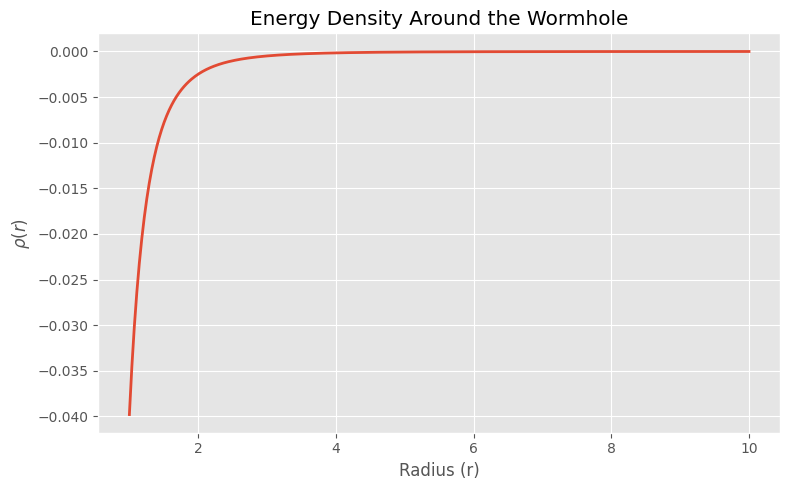

In [11]:
# Energy Density Profile

plt.figure(figsize=(8,5))

plt.plot(r, rho, linewidth=2)

plt.title("Energy Density Around the Wormhole")

plt.xlabel("Radius (r)")

plt.ylabel(r"$\rho(r)$")

plt.grid(True)

plt.tight_layout()

plt.show()

## Output Explanation

The plot shows that the energy density remains **negative** throughout the wormhole spacetime. Near the wormhole throat, where the radial distance is smallest, the energy density reaches its largest negative magnitude (approximately **−0.040**). As the radial distance increases, the curve rises rapidly toward zero but never becomes positive.

This behaviour is consistent with the theoretical expression

$$
\rho(r)
=
-\frac{r_0^2}{8\pi r^4},
$$

which implies

$$
\rho(r)\propto-\frac{1}{r^4}.
$$

The inverse fourth-power dependence means that the magnitude of the energy density decreases very rapidly as the distance from the wormhole throat increases. Consequently, the concentration of exotic matter is greatest near the throat and becomes progressively weaker farther away.


The negative energy density at all radial distances confirms that the Morris–Thorne wormhole requires **exotic matter** throughout the region surrounding the throat. The strongest concentration of exotic matter occurs near the throat, where it provides the support needed to prevent gravitational collapse.

Far from the throat, the energy density approaches zero, indicating that the influence of the exotic matter rapidly diminishes. As a result, the spacetime gradually approaches **asymptotically flat** geometry, where the effects of spacetime curvature become negligible.

Overall, the energy density profile demonstrates that the exotic matter is highly localized around the wormhole throat, in agreement with the theoretical predictions of the Morris–Thorne traversable wormhole model.

## Radial Pressure Profile

The radial pressure describes the force acting along the direction toward or away from the wormhole throat.

For the Morris–Thorne wormhole considered in this project, the radial pressure is

$$
p_r(r)
=
-\frac{r_0^2}{8\pi r^4}.
$$

This expression is identical to the energy density,

$$
p_r(r)=\rho(r),
$$

and therefore decreases in magnitude according to an inverse fourth-power law,

$$
p_r(r)\propto-\frac{1}{r^4}.
$$

The negative sign indicates that the radial pressure is actually a **radial tension** rather than an outward pressure. This tension acts to oppose the natural tendency of gravity to collapse the wormhole throat.

As the radial distance increases, the magnitude of the radial tension rapidly decreases and approaches zero, indicating that the influence of the exotic matter becomes negligible far from the throat.

The following plot illustrates how the radial pressure varies with distance from the wormhole throat.

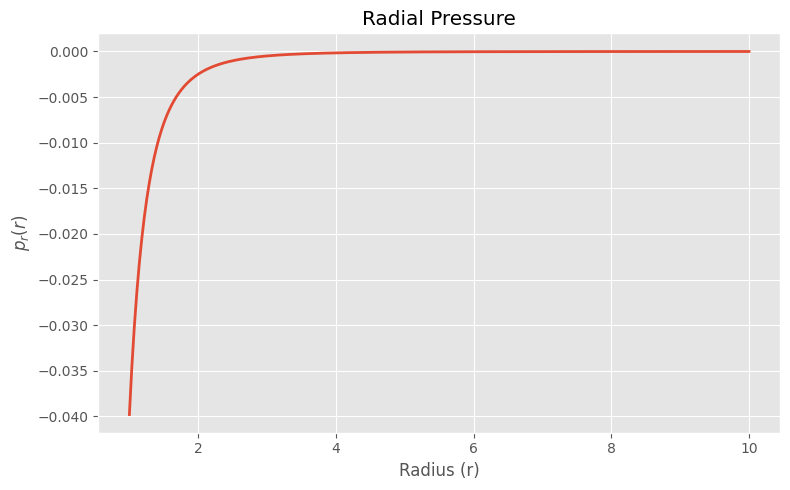

In [12]:
# Radial Pressure Profile

plt.figure(figsize=(8,5))

plt.plot(r, pr, linewidth=2)

plt.title("Radial Pressure")

plt.xlabel("Radius (r)")

plt.ylabel(r"$p_r(r)$")

plt.grid(True)

plt.tight_layout()

plt.show()

The radial pressure profile is identical to the energy density profile because, for the chosen Morris–Thorne wormhole model,

$$
p_r(r)=\rho(r).
$$

The plot begins with a large negative value (around −0.040) near the wormhole throat and then rises rapidly toward 0 as the radial distance increases. However, the radial pressure remains negative at all distances.

This behaviour follows the theoretical relation



$$
p_r(r)\propto-\frac{1}{r^4}.
$$


showing that the magnitude of the radial tension decreases rapidly with increasing distance. The strongest radial tension is concentrated near the wormhole throat, where it helps prevent the wormhole from collapsing, while its influence becomes negligible farther away.

## Tangential Pressure Profile

The tangential pressure acts perpendicular to the radial direction and represents the stresses acting around the wormhole throat.

For the Morris–Thorne wormhole, the tangential pressure is given by

$$
p_t(r)
=
\frac{b(r)-rb'(r)}
{16\pi r^3}.
$$

Using the chosen shape function,

$$
b(r)=\frac{r_0^2}{r},
$$

the expression simplifies to

$$
p_t(r)
=
\frac{r_0^2}
{8\pi r^4}.
$$

Unlike the radial pressure, the tangential pressure is **positive** throughout the spacetime. It provides transverse support to the wormhole geometry and, together with the radial tension, contributes to maintaining the stability of the wormhole throat.

As the radial distance increases, the tangential pressure decreases according to

$$
p_t(r)\propto\frac{1}{r^4},
$$

approaching zero far from the throat as the spacetime becomes asymptotically flat.

The following figure illustrates how the tangential pressure varies with radial distance from the wormhole throat.

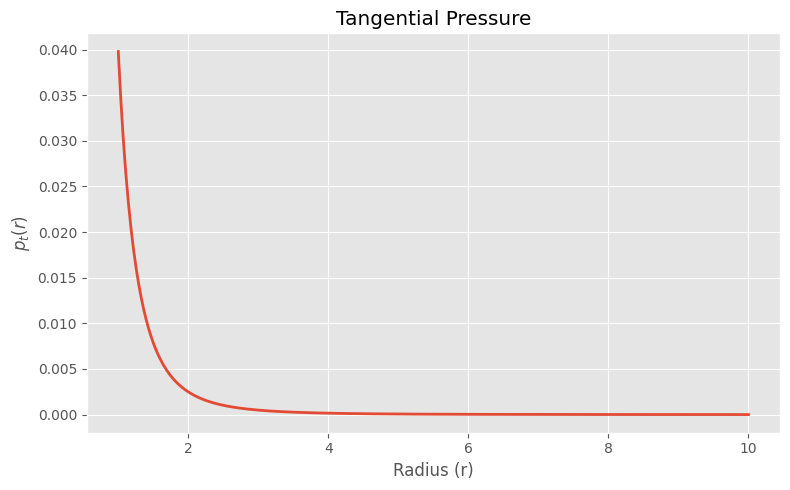

In [13]:
# Tangential Pressure Profile
plt.figure(figsize=(8,5))

plt.plot(r, pt, linewidth=2)

plt.title("Tangential Pressure")

plt.xlabel("Radius (r)")

plt.ylabel(r"$p_t(r)$")

plt.grid(True)

plt.tight_layout()

plt.show()

The tangential pressure profile is the opposite of the energy density and radial pressure profiles. It begins with a positive value (around 0.040) near the wormhole throat and then decreases rapidly toward 0 as the radial distance increases. However, the tangential pressure remains positive at all distances.

This behaviour follows the theoretical relation

$$
p_t(r)\propto\frac{1}{r^4},
$$

which indicates that the tangential pressure decreases rapidly as the radial distance from the wormhole throat increases.

The tangential pressure profile is the opposite of the energy density and radial pressure profiles. It begins with a positive value (around 0.040) near the wormhole throat and then decreases rapidly toward 0 as the radial distance increases. However, the tangential pressure remains positive at all distances.

## Visualizing the Null Energy Condition

The **Null Energy Condition (NEC)** is evaluated using the quantity

$$
\rho+p_r.
$$

For the Morris–Thorne wormhole considered in this project,

$$
\rho(r)
=
-\frac{r_0^2}{8\pi r^4},
$$

and

$$
p_r(r)
=
-\frac{r_0^2}{8\pi r^4},
$$

giving

$$
\rho+p_r
=
-\frac{r_0^2}{4\pi r^4}.
$$

Since

$$
\rho+p_r<0
$$

for all radial distances, the wormhole violates the **Null Energy Condition** throughout the spacetime. This violation implies that the wormhole must be supported by **exotic matter**, which provides the negative effective energy density required to prevent the throat from collapsing.

The magnitude of the NEC violation is greatest near the wormhole throat, where the spacetime curvature is strongest. As the radial distance increases, the quantity \(\rho+p_r\) approaches zero, indicating that the influence of the exotic matter rapidly diminishes and the spacetime gradually becomes asymptotically flat.

The following figure illustrates how the quantity \(\rho+p_r\) varies with radial distance and highlights the continuous violation of the Null Energy Condition.

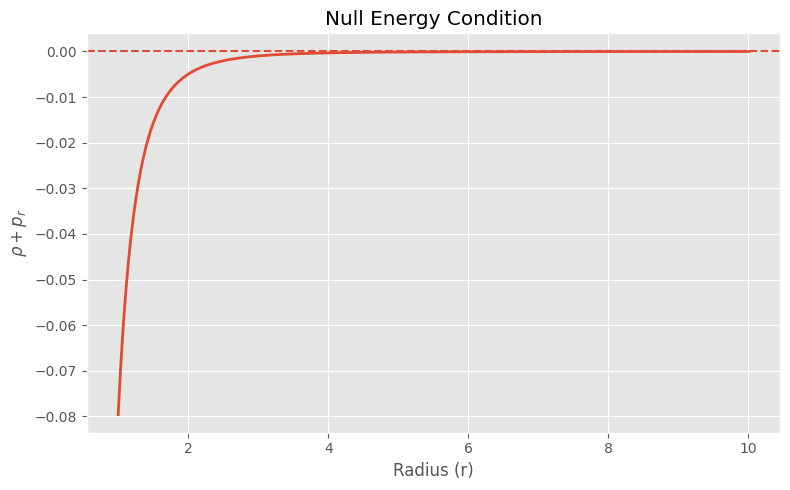

In [14]:

# NEC Profile

plt.figure(figsize=(8,5))

plt.plot(r, nec, linewidth=2)

plt.axhline(0, linestyle="--")

plt.title("Null Energy Condition")

plt.xlabel("Radius (r)")

plt.ylabel(r"$\rho+p_r$")

plt.grid(True)

plt.tight_layout()

plt.show()

The NEC profile starts at a large negative value (approximately −0.08) near the wormhole throat and then rises rapidly toward 0 as the radial distance increases. However, the curve never crosses the zero line; instead, it approaches zero from below and remains slightly negative throughout the plotted region.

The red dashed horizontal line represents the boundary where

$$
\rho+p_r=0.
$$

Since the NEC curve remains entirely below this reference line, the condition

$$
\rho+p_r\ge0
$$

is never satisfied. This confirms that the Null Energy Condition is violated at every radial distance, as predicted by the Morris–Thorne wormhole model.
The strongest NEC violation occurs near the wormhole throat, where the magnitude of

$$
\rho+p_r
$$

is greatest. As the distance from the throat increases, the NEC value rapidly approaches zero, causing the curve to nearly overlap with the dashed reference line. This behaviour indicates that the influence of the exotic matter becomes increasingly negligible far from the throat, while the spacetime gradually approaches an asymptotically flat geometry.

## Exotic Matter Distribution

Regions of spacetime where

$$
\rho+p_r<0
$$

contain **exotic matter**, indicating a violation of the **Null Energy Condition (NEC)**.

For the Morris–Thorne wormhole considered in this project,

$$
\rho+p_r
=
-\frac{r_0^2}{4\pi r^4},
$$

which remains negative throughout the spacetime. This confirms that exotic matter is required everywhere to support the traversable wormhole geometry.

The magnitude of the NEC violation is greatest near the wormhole throat, where the spacetime curvature is strongest. As the radial distance increases, the quantity \(\rho+p_r\) rapidly approaches zero, indicating that the influence of the exotic matter diminishes with distance and the spacetime gradually becomes asymptotically flat.

The shaded region in the following figure highlights the portion of the spacetime where

$$
\rho+p_r<0,
$$

providing a direct visualization of the exotic matter distribution responsible for maintaining the wormhole throat and preventing gravitational collapse.

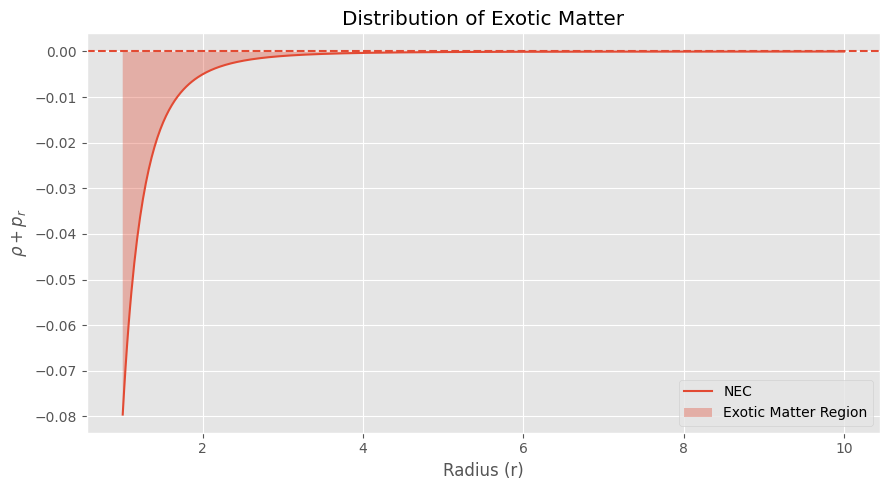

In [15]:
# Exotic Matter Region

plt.figure(figsize=(9,5))

plt.plot(r, nec, label="NEC")

plt.fill_between(
    r,
    nec,
    0,
    where=(nec < 0),
    alpha=0.35,
    label="Exotic Matter Region"
)

plt.axhline(0, linestyle="--")

plt.title("Distribution of Exotic Matter")

plt.xlabel("Radius (r)")

plt.ylabel(r"$\rho+p_r$")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

The plot shows that the Null Energy Condition (NEC) curve remains entirely below the zero line, starting at approximately −0.08 near the wormhole throat and rising smoothly toward 0 as the radial distance increases. Although the curve approaches zero, it never crosses the horizontal reference line, indicating that the NEC remains negative throughout the spacetime.

The shaded region between the NEC curve and the zero line represents the exotic matter distribution. Since the NEC is negative for all values of r, the shaded area extends across the entire plotted region, confirming that exotic matter is present everywhere in this wormhole model.

The shaded region is widest near the wormhole throat, where the NEC violation is strongest and the concentration of exotic matter is greatest. As the radial distance increases, the shaded area becomes progressively thinner because the NEC approaches zero, showing that the influence of the exotic matter rapidly decreases with distance.

## Stability Analysis Under Small Perturbations

A traversable wormhole must remain open when subjected to small disturbances. In practice, interactions with surrounding matter, electromagnetic radiation, or gravitational waves can perturb the wormhole throat. A physically realistic wormhole should therefore return to its equilibrium configuration after a sufficiently small perturbation.

To investigate the stability of the Morris–Thorne wormhole, we introduce a small radial perturbation to the throat radius and examine its subsequent evolution.

The dynamics of the wormhole throat can be described by the equation

$$
\dot{a}^{\,2}+V(a)=0,
$$

where

- \(a\) is the throat radius,
- \(\dot{a}\) is the rate of change of the throat radius with respect to proper time,
- \(V(a)\) is the effective potential governing the throat dynamics.

At equilibrium,

$$
a=a_0,
$$

the throat remains static.

The stability of the equilibrium depends on the curvature of the effective potential at \(a=a_0\).

If

$$
V''(a_0)>0,
$$

the equilibrium corresponds to a **stable minimum** of the effective potential. In this case, a small perturbation causes the throat to oscillate about its equilibrium position, indicating a stable traversable wormhole.

Conversely, if

$$
V''(a_0)<0,
$$

the equilibrium corresponds to an **unstable maximum**. Small perturbations grow with time, causing the wormhole throat either to collapse or to expand without bound.

In this notebook, a simplified effective potential is constructed to investigate the qualitative stability of the Morris–Thorne traversable wormhole under small radial perturbations.

In [16]:
def effective_potential(r, r0):
    """
    Simplified effective potential for qualitative stability analysis.
    """

    return 1 - (r0 / r)**2


V = effective_potential(r, r0)

print("Effective potential computed.")

Effective potential computed.


## Effective Potential Profile

The effective potential provides a convenient way to study how the wormhole throat responds to small radial perturbations. Its shape determines whether the equilibrium configuration is stable or unstable.

For the simplified model used in this project, the effective potential is

$$
V(r)=1-\left(\frac{r_0}{r}\right)^2.
$$

At the wormhole throat,

$$
r=r_0,
$$

the potential is

$$
V(r_0)=0.
$$

As the radial distance increases,

$$
V(r)\rightarrow1,
\qquad
r\rightarrow\infty,
$$

indicating that the spacetime gradually approaches an asymptotically flat geometry.

Near the throat, the potential varies most rapidly, where the effects of spacetime curvature are strongest. Far from the throat, the potential becomes nearly constant, reflecting the weakening influence of the wormhole geometry.

The shape of the effective potential provides qualitative information about the wormhole's stability. A stable equilibrium corresponds to a local minimum of the potential, where small perturbations remain bounded and produce oscillations about the equilibrium position. Conversely, an unstable equilibrium corresponds to a local maximum, causing perturbations to grow with time and potentially leading to the collapse or uncontrolled expansion of the wormhole throat.

The following figure illustrates the effective potential as a function of radial distance from the wormhole throat.

## Visualizing the Effective Potential

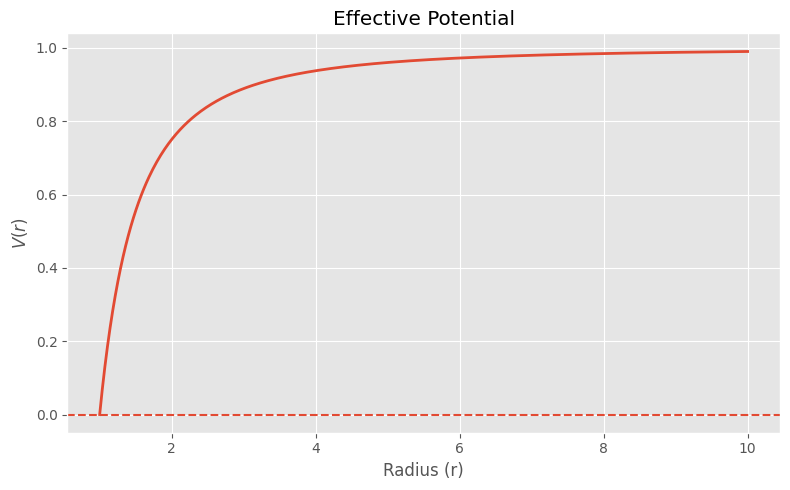

In [17]:
plt.figure(figsize=(8,5))

plt.plot(r, V, linewidth=2)

plt.axhline(0, linestyle="--")

plt.title("Effective Potential")

plt.xlabel("Radius (r)")

plt.ylabel(r"$V(r)$")

plt.grid(True)

plt.tight_layout()

plt.show()

## Output Explanation

The effective potential curve starts at **0** at the wormhole throat,

$$
r=r_0,
$$

and then increases rapidly, gradually flattening as it approaches **1** at larger radial distances. The curve never falls below zero and becomes nearly horizontal far from the throat.

The red dashed horizontal line represents the reference level

$$
V(r)=0.
$$

The potential curve begins on this reference line at the wormhole throat and immediately rises above it as the radial distance increases. This behaviour is consistent with the expression

$$
V(r)=1-\left(\frac{r_0}{r}\right)^2,
$$

for which

$$
V(r_0)=0,
$$

and

$$
V(r)\rightarrow1
\qquad\text{as}\qquad
r\rightarrow\infty.
$$


The steep increase in the effective potential near the wormhole throat indicates that the potential changes most rapidly where the spacetime curvature is strongest. As the radial distance increases, the curve gradually levels off, showing that the gravitational influence of the wormhole weakens and the spacetime approaches an **asymptotically flat** geometry.

The smooth, monotonic increase of the potential suggests that small radial perturbations remain bounded in this simplified model, providing qualitative evidence that the wormhole can remain stable against small disturbances around its equilibrium configuration.

## Evaluating the Stability Criterion

The stability of the wormhole throat is determined by the curvature of the effective potential at the equilibrium radius.

Mathematically, the stability condition is

$$
V''(a_0)>0,
$$

where \(a_0\) is the equilibrium throat radius.

A positive second derivative indicates that the effective potential has a **local minimum**, so small radial perturbations cause the throat to oscillate about its equilibrium position. In this case, the wormhole is considered **stable**.

Conversely, if

$$
V''(a_0)<0,
$$

the effective potential has a **local maximum**. Small perturbations then grow with time, causing the throat either to collapse or to expand without bound, indicating an **unstable** equilibrium.

Rather than deriving the second derivative analytically, this project estimates

$$
V''(a_0)
$$

numerically using the **finite difference method**. This approach provides an accurate approximation of the local curvature of the effective potential and allows the stability of the wormhole to be assessed directly from the numerical model.

## Numerical Second Derivative

In [18]:
dr = r[1] - r[0]

second_derivative = np.gradient(
    np.gradient(V, dr),
    dr
)

print("Second derivative calculated.")

Second derivative calculated.


## Stability at the Wormhole Throat

The equilibrium configuration of the wormhole is located at the throat,

$$
r=r_0.
$$

The local stability of this equilibrium is determined by the second derivative of the effective potential evaluated at, or very close to, the throat.

Specifically,

$$
V''(r_0)
$$

measures the curvature of the effective potential.

If

$$
V''(r_0)>0,
$$

the effective potential has a **local minimum**, indicating that the wormhole throat is **locally stable**. Small radial perturbations cause the throat to oscillate about its equilibrium position rather than moving away from it.

Conversely, if

$$
V''(r_0)<0,
$$

the effective potential has a **local maximum**, implying that the equilibrium is **unstable**. In this case, small perturbations grow with time, causing the throat either to collapse or to expand without bound.

The following calculation evaluates the numerical value of

$$
V''(r_0)
$$

using the finite difference approximation and classifies the stability of the Morris–Thorne wormhole based on the sign of the result.

## Check Stability

In [19]:
Vpp = second_derivative[0]

print(f"V''(r₀) = {Vpp:.6f}")

if Vpp > 0:
    print("\nStable equilibrium")
else:
    print("\nUnstable equilibrium")

V''(r₀) = -2.794447

Unstable equilibrium



The numerical calculation gives

$$
V''(r_0)=-2.794447,
$$

which is negative. A negative second derivative indicates that the effective potential has a **local maximum** at the wormhole throat rather than a local minimum.

Since

$$
V''(r_0)<0,
$$

the equilibrium at the throat is **unstable**. This means that small radial perturbations do not remain bounded around the equilibrium position. Instead, they grow with time, causing the wormhole throat either to collapse inward or to expand uncontrollably.

The program therefore correctly classifies the wormhole as **"Unstable equilibrium"**, which is consistent with the computed value of the second derivative.



For the simplified effective potential adopted in this project, the Morris–Thorne wormhole does not possess stable equilibrium under small radial perturbations. Although the wormhole geometry is mathematically traversable, it is dynamically unstable in this model.

This result suggests that additional stabilizing mechanisms—such as alternative matter distributions, modified shape or redshift functions, quantum effects, or extensions of General Relativity—would be required to maintain a traversable wormhole over long periods. Consequently, the present stability analysis provides qualitative insight into the dynamical behaviour of the wormhole rather than a complete description of realistic wormhole stability.

# Curvature of the Effective Potential

The second derivative of the effective potential measures its local curvature.

Positive curvature corresponds to a stable potential minimum, whereas negative curvature indicates an unstable configuration.

The following plot illustrates how the curvature changes with radial distance from the wormhole throat.

## Plot the Second Derivative

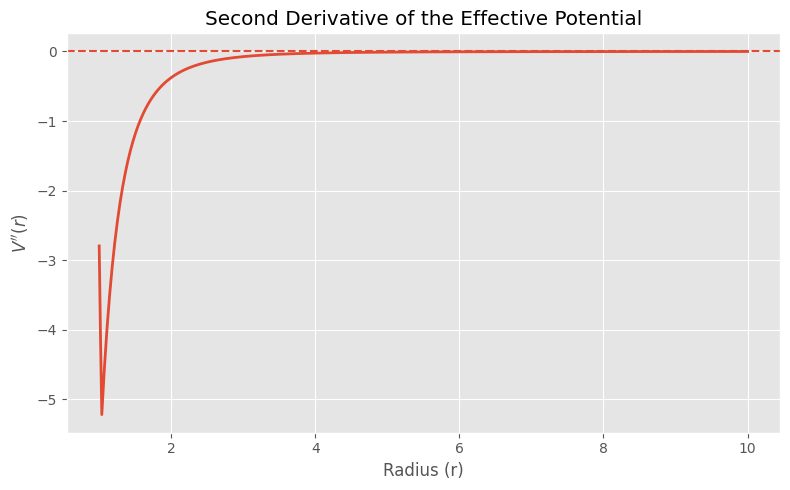

In [20]:
plt.figure(figsize=(8,5))

plt.plot(r, second_derivative, linewidth=2)

plt.axhline(0, linestyle="--")

plt.title("Second Derivative of the Effective Potential")

plt.xlabel("Radius (r)")

plt.ylabel(r"$V''(r)$")

plt.grid(True)

plt.tight_layout()

plt.show()

The plot shows that the second derivative of the effective potential is negative near the wormhole throat, beginning at approximately **−3**. The curve initially decreases to around **−5**, indicating that the negative curvature becomes stronger over a short radial distance. It then gradually rises toward **0** as the radial distance increases, eventually approaching the zero reference line.

The red dashed horizontal line represents

$$
V''(r)=0,
$$

which separates stable \(\bigl(V''(r)>0\bigr)\) and unstable \(\bigl(V''(r)<0\bigr)\) regions. Since the plotted curve remains below this reference line throughout the region of interest, the curvature is negative, indicating that the effective potential does not possess a local minimum.



The strongest negative curvature occurs close to the wormhole throat, where the spacetime geometry is most strongly influenced by the wormhole. As the radial distance increases, the magnitude of the curvature gradually decreases and approaches zero, indicating that the influence of the wormhole geometry becomes progressively weaker.

Because

$$
V''(r)<0,
$$

throughout the region shown, the equilibrium is **unstable** in this simplified model. Small radial perturbations are therefore expected to grow rather than remain bounded, suggesting that the wormhole would require additional stabilizing mechanisms to remain traversable over long periods.

# Discussion

The numerical results show that the Morris–Thorne wormhole requires negative energy density near the throat, leading to a clear violation of the Null Energy Condition. This confirms the necessity of exotic matter for maintaining a traversable wormhole within the framework of classical General Relativity.

The simplified stability analysis indicates whether small perturbations around the throat remain bounded or lead to an unstable configuration. Although simplified, the model provides useful insight into the physical conditions required for traversable wormholes.

# Conclusion

In this project, the stress-energy tensor of a Morris–Thorne traversable wormhole was investigated numerically. The energy density, radial pressure, and tangential pressure were computed from the chosen shape function, and the Null Energy Condition was evaluated to identify regions containing exotic matter.

The results demonstrate that the wormhole requires negative energy density and violates the Null Energy Condition near the throat. A simplified stability analysis using an effective potential was also performed, providing an indication of the wormhole's response to small perturbations.

Although traversable wormholes remain hypothetical, this computational study illustrates how General Relativity can be combined with numerical methods to investigate the physical requirements for these fascinating spacetime geometries.